In [1]:
from collections import defaultdict
from Bio.SeqIO.FastaIO import SimpleFastaParser as sfp
from Bio import SeqIO, SearchIO, Entrez
import seaborn as sns
import pandas as pd
import os, glob, math, re, gzip, skbio, time
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import warnings
from Bio import Entrez
#warnings.filterwarnings('ignore')
Entrez.email = "ajaffe@stanford.edu"

In [2]:
def cmdir(path):
    if not os.path.isdir(path):
        os.mkdir(path)

def scaffold(gene):
    if gene != "None":
        try: return re.search("(.+?)_[0-9]+$", gene).group(1)
        except: print(gene)

def sbatch(name, cpus, cmd):
    return "sbatch -J %s -p serc -t 1- -c %d --mem %dG --wrap '%s'" %(name, cpus, cpus*8, cmd)

In [3]:
import sys
sys.path.insert(0, '/home/users/ajaffe/notebooks/modules/')
import parse

In [4]:
rootdir = "/scratch/users/ajaffe/rubisco-div/"
cmdir(rootdir)

## build sequence set

In [5]:
cmdir(rootdir + "sequences")
cmdir(rootdir + "tables")

### nr and env-nr

In [7]:
# searches
for fasta in glob.glob("/oak/stanford/groups/dekas/db/*nr/*fa"):
    
    name = os.path.basename(fasta).split(".")[0]
    call = "hmmsearch --cpu 20 --domtblout %s \
                %s %s" %(rootdir + "sequences/" + name + ".results",
                "/home/groups/dekas/ajaffe/hmms/rubisco/rubisco_all_profiles.hmm", fasta)
    print(sbatch("NR", 20, call))

sbatch -J NR -p serc -t 1- -c 20 --mem 160G --wrap 'hmmsearch --cpu 20 --domtblout /scratch/users/ajaffe/rubisco-div/sequences/nr.results                 /home/groups/dekas/ajaffe/hmms/rubisco/rubisco_all_profiles.hmm /oak/stanford/groups/dekas/db/nr/nr.fa'
sbatch -J NR -p serc -t 1- -c 20 --mem 160G --wrap 'hmmsearch --cpu 20 --domtblout /scratch/users/ajaffe/rubisco-div/sequences/env_nr.results                 /home/groups/dekas/ajaffe/hmms/rubisco/rubisco_all_profiles.hmm /oak/stanford/groups/dekas/db/env_nr/env_nr.fa'


In [9]:
# parse and write out hits

for result in glob.glob(rootdir + "sequences/*results"):
    
    name = os.path.basename(result).split(".")[0]
    hmm_results = parse.domtable(result)
    # choose best hmm and filter by hmm cov
    hmm_results = hmm_results.sort_values("score", ascending=False).drop_duplicates("gene").query("hmm_overall_cov>=0.90")
    # modify hmm names
    hmm_results = hmm_results.replace("I_all", "I").replace("IV_all", "IV").replace("II_II", "II")

    with open(rootdir + "sequences/" + name + ".txt", "w") as out:
        for key, row in hmm_results.iterrows():
            out.write(row["gene"] + "\n")
            
    print("blastdbcmd -db %s -entry_batch %s -out %s.fa" %("/$OAK/db/" + name + "/" + name,
                                                           name + ".txt", name + ".extracted"))

blastdbcmd -db /$OAK/db/nr/nr -entry_batch nr.txt -out nr.extracted.fa
blastdbcmd -db /$OAK/db/env_nr/env_nr -entry_batch env_nr.txt -out env_nr.extracted.fa


Rezip big fasta db's at this point.

In [18]:
# if a subset of existing sequence set
for seqlist in glob.glob(rootdir + "sequences/*nr.txt"):
    
    name = os.path.basename(seqlist).split(".")[0]
    
    seqdict = {} #store original sequence full header + aa
    for record in sfp(open(rootdir + "sequences/" + name + ".extracted.fa")):
        seqdict[record[0].split(" ")[0]] = {"header": record[0], "seq": record[1]}
        
    with open(rootdir + "sequences/" + name + ".subset.fa", "w") as out:
        for line in open(seqlist).readlines():
            out.write(">%s\n%s\n" %(seqdict[line.strip()]["header"], seqdict[line.strip()]["seq"]))

### winter olympics

In [9]:
# buffers to hold characterization data
attempted = []
succeeded = []

In [10]:
kcats = ["WP_110780429.1", "Candidatus_Lokiarchaeota_archaeon_strain_HM5_B55|JABCTP010000089_12",
         "anaerobic_archaeon_MK-D1|CP042905_1239", "MBU1445715.1",
         "MBU2523915.1", "NPA75613.1", "MBI5465798.1"]

In [11]:
winter_olympics = pd.read_csv(rootdir + "tables/rubisco_picking.tsv", sep="\t")

with open(rootdir + "sequences/winter_olympics.fa", "w") as out:
    for key, row in winter_olympics.iterrows():
        out.write(">%s\n%s\n" %(row["Accession ID"], row["Sequence"]))
        
        if row["Accession ID"].split(" ")[0] in kcats:
            succeeded.append(row["Accession ID"])
        else:
            attempted.append(row["Accession ID"])

Also place liu_et_al_sequences.faa in directory (targeting I'' and I-alpha).

### other kinetics papers

In [12]:
# depins and davidi
depins = pd.read_csv(rootdir + "tables/depins_et_al_2023.csv").fillna("None")

with open(rootdir + "sequences/depins.fa", "w") as out:
    for key, row in depins.iterrows():
        out.write(">%s\n%s\n" %(row["Identifier"], row["Large subunit"]))
        
        if row["Rate mean [s-1]"] != "None":
            succeeded.append(row["Identifier"])    
        else: 
            attempted.append(row["Identifier"])
        
davidi = pd.read_csv(rootdir + "tables/davidi_et_al_2020.csv").fillna("None")

with open(rootdir + "sequences/davidi.fa", "w") as out:
    for key, row in davidi.iterrows():
        out.write(">%s\n%s\n" %(row["Identifier"], row["Protein seq"]))
        
        if row["Rate mean [s-1] "] != "None":
            succeeded.append(row["Identifier"])    
        else: 
            attempted.append(row["Identifier"])

In [13]:
# flamholz and galmes
prywes = pd.read_csv(rootdir + "tables/prywes_et_al.csv").fillna("None")
flamholz = pd.read_csv(rootdir + "tables/flamholz_et_al_2019.csv")
flamholz["species_stripped"] = flamholz["species"].apply(lambda x: x.strip())

missing = []
with open(rootdir + "sequences/flamholz.fa", "w") as out:
    
    for key, row in flamholz.drop_duplicates("species_stripped").iterrows():

        table = prywes[prywes["Species"]==row["species_stripped"].strip()]
        
        if len(table) != 0:
            
            table = table.sort_values("Sequence_Length_Amino_Acids", ascending=False)

            if row["species_stripped"] == "Rhodospirillum rubrum":
                table = table.query("Sequence_Length_Amino_Acids=='466'")
                
            out.write(">%s\n%s\n" %(table["NCBI_Accession_ID"].iloc[0], table["Sequence"].iloc[0]))
            succeeded.append(table["NCBI_Accession_ID"].iloc[0])
        
        else: missing.append(row["species_stripped"])
            
with open(rootdir + "sequences/flamholz_missing.txt", "w") as out:
    for item in sorted(missing):
        out.write(item + "\n")

In [14]:
# galmes
all_species = set()

for table in glob.glob(rootdir + "tables/galmes*"):
    for key, row in pd.read_csv(table, encoding='ISO-8859-1').dropna(subset=["Species"]).iterrows():
        all_species.add(row["Species"].strip())

missing = []
with open(rootdir + "sequences/galmes.fa", "w") as out:
    
    for species in all_species:

        table = prywes[prywes["Species"]==species.strip()]

        if len(table) != 0:
            
            table = table.sort_values("Sequence_Length_Amino_Acids", ascending=False)

            if species == "Rhodospirillum rubrum":
                table = table.query("Sequence_Length_Amino_Acids=='466'")

            out.write(">%s\n%s\n" %(table["NCBI_Accession_ID"].iloc[0], table["Sequence"].iloc[0]))
            succeeded.append(table["NCBI_Accession_ID"].iloc[0])

        else: missing.append(species)
            
with open(rootdir + "sequences/galmes_missing.txt", "w") as out:
    for item in sorted(missing):
        out.write(item + "\n")

In [15]:
# de pins et al. 2025 (slo rubisco)
slo = pd.read_csv(rootdir + "tables/slo_rubisco_paper.csv")

with open(rootdir + "sequences/slo.fa", "w") as out:
    for key, row in slo.iterrows():
        out.write(">%s\n%s\n" %(row["identifier"], row["large_subunit"]))
        succeeded.append(row["identifier"])

### size filtering

In [46]:
lens = []
info = defaultdict(list)

for fa in glob.glob(rootdir + "sequences/*fa"):
    
    if "extracted" not in fa:

        if "/nr." in fa: #dataset naming
            prefix = "NRX"
        else: prefix = os.path.basename(fa)[0:3].upper()
        
        for record in sfp(open(fa)):
            
            info["dataset"].append(prefix)
            
            if prefix == "WIN":
                clean = record[0].split(" ")[0].split("|")[0]
            else: clean = record[0].split(" ")[0]
                
            info["header_clean"].append(clean)
            info["header_full"].append(record[0])
            info["sequence_len_aa"].append(len(record[1]))
            info["sequence"].append(record[1])
            lens.append(len(record[1]))

infodf = pd.DataFrame(info).sort_values("sequence_len_aa", ascending=False)
infodf.to_csv(rootdir + "prelim_sequence_info.csv", index=False)
infodf.head()

,dataset,header_clean,header_full,sequence_len_aa,sequence
476,FLA,KAH0643467.1,KAH0643467.1,1030,MSCREGFMSPQTETKASVGFKAGVKEYKLTYYTPEYQTKDTDILAA...
583,GAL,KAH0643467.1,KAH0643467.1,1030,MSCREGFMSPQTETKASVGFKAGVKEYKLTYYTPEYQTKDTDILAA...
792,GAL,PHT98340.1,PHT98340.1,820,MSCREGFMSPQIETKASVGFKAGVKEYKLTYYTIEYQTKDTDILAA...
474,FLA,KAF3638252.1,KAF3638252.1,818,MSCREGFMSPQIETKESVGFKAGVKEYKLTYYTIEYQTKDTDILAT...
813,GAL,KAF3638252.1,KAF3638252.1,818,MSCREGFMSPQIETKESVGFKAGVKEYKLTYYTIEYQTKDTDILAT...


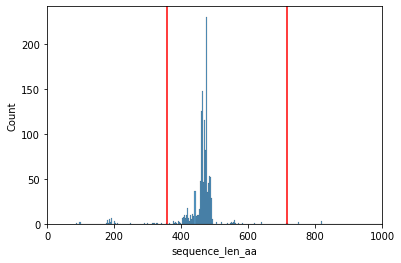

In [47]:
wmax = infodf.query("dataset=='WIN'")["sequence_len_aa"].max()
wmin = infodf.query("dataset=='WIN'")["sequence_len_aa"].min()

sns.histplot(lens)
plt.axvline(wmax, color="red")
plt.axvline(wmin, color="red")
plt.xlabel("sequence_len_aa")
plt.xlim([0,1000])
plt.savefig(rootdir + "sequence_lens.svg", format="svg")
plt.show()

In [48]:
with open(rootdir + "sequences/all_rubisco.faa", "w") as out:
    for key, row in infodf.iterrows():
        if (row["sequence_len_aa"]>=wmin) and (row["sequence_len_aa"]<=wmax):
            out.write(">%s_%s\n%s\n" %(row["dataset"], row["header_clean"], row["sequence"]))

### kegg filtering

In [164]:
# launch kofamscan
kocall = "exec_annotation -o %s %s -p %s -k %s --cpu 20 -f detail" \
    %(rootdir + "sequences/all_rubisco_size.kfscan.txt", rootdir + "sequences/all_rubisco.faa",
     "/home/groups/dekas/software/kofamscan/profiles/prokaryote.hal",
      "/home/groups/dekas/software/kofamscan/ko_list")
print(sbatch("kofamscan", 20, kocall))

sbatch -J kofamscan -p serc -t 1- -c 20 --mem 160G --wrap 'exec_annotation -o /scratch/users/ajaffe/rubisco-div/sequences/all_rubisco_size.kfscan.txt /scratch/users/ajaffe/rubisco-div/sequences/all_rubisco.faa -p /home/groups/dekas/software/kofamscan/profiles/prokaryote.hal -k /home/groups/dekas/software/kofamscan/ko_list --cpu 20 -f detail'


In [31]:
# filter for significance
kodf = parse.kofamscan(rootdir + "sequences/all_rubisco.kfscan.txt", 1e-5)
kodf["eval"] = kodf["eval"].apply(lambda x: float(x))
kodf["score"] = kodf["score"].apply(lambda x: float(x))
# get best hit per gene based on score
kfilt = kodf.sort_values('score', ascending=False).drop_duplicates("gene")
kfilt["ko"].value_counts()[0:10]

K01601    71372
K08965     5752
K01559     4437
K25035     2913
K24268     1659
Name: ko, dtype: int64

In [32]:
inputted = [record[0] for record in sfp(open(rootdir + "sequences/all_rubisco.faa"))]
len(inputted)

86807

In [33]:
len(kfilt)

86133

In this case, no need to trim anything from the dataset.

## clustering and representative selection

### cluster

In [34]:
thresholds = [i for i in range(50, 100, 5)] + [99]

with open(rootdir + "sequences/cluster.sh", "w") as out:
    
    for threshold in thresholds:

        decimal = threshold/float(100)
        call = "usearch -threads 20 -cluster_fast %s -id %.2f -sort length -centroids %s --uc %s" \
            %(rootdir + "sequences/all_rubisco.faa", decimal, \
              rootdir + "sequences/all_rubisco.centroids." + str(threshold) + ".faa", \
              rootdir + "sequences/all_rubisco." + str(threshold) + ".clusters")
        out.write(call + "\n")

In [36]:
# rough pass at form assignments
call = "hmmsearch --cpu 20 --domtblout %s \
            %s %s" %(rootdir + "sequences/all_rubisco.results",
            "/home/groups/dekas/ajaffe/hmms/rubisco/rubisco_all_profiles.hmm", rootdir + "sequences/all_rubisco.faa")
#print(call)

all_results = parse.domtable(rootdir + "sequences/all_rubisco.results")
all_results = all_results.sort_values("score", ascending=False).drop_duplicates("gene")
all_results = all_results.replace("I_all", "I").replace("IV_all", "IV").replace("II_II", "II").replace("II_III_II_III", "II/III")
prelim_forms = {row["gene"]: row["hmm"] for key, row in all_results.iterrows()}

In [37]:
runinfo = defaultdict(list)

for run in glob.glob(rootdir + "sequences/*clusters"):
    
    threshold = os.path.basename(run).split(".")[1]
    table = parse.usearch(run)
    
    #quality check
    if len(table["sequence"].unique()) != len(table):
        print("uh oh! duplicate cluster assigment on %s." %(run))
        
    table["prelim_form"] = table["sequence"].map(prelim_forms)
    
    form_counts = {"all":0, "mixed":0}
    for form in set(prelim_forms.values()):
        form_counts[form]=0
    
    for cluster in table["cluster"].unique():
        
        subtable = table[table["cluster"]==cluster]
        forms = list(subtable["prelim_form"])
        
        if len(set(forms)) == 1:
            form_counts[forms[0]] +=1
        else: form_counts["mixed"] +=1
        form_counts["all"] +=1
        
    for form in form_counts.keys():
        runinfo["threshold"].append(threshold)
        runinfo["cluster_form"].append(form)
        runinfo["cluster_count"].append(form_counts[form])

rundf = pd.DataFrame(runinfo).sort_values(["threshold", "cluster_count"])
rundf.head()

,threshold,cluster_form,cluster_count
103,50,III_Transaldolase,0
101,50,II/III,1
107,50,III_Like,2
105,50,II,4
104,50,I,8


### visualize

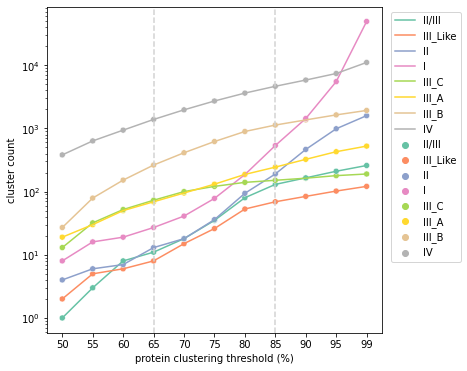

In [38]:
plt.figure(figsize=[6,6])
sns.lineplot(x="threshold", y="cluster_count",
             data=rundf[rundf["cluster_form"].isin(["I", "II", "III_C", "III_A", 
                "III_B", "IV", "II/III", "III_Like"])],
             hue="cluster_form", palette="Set2")
sns.scatterplot(x="threshold", y="cluster_count",
             data=rundf[rundf["cluster_form"].isin(["I", "II", "III_C", "III_A", 
                "III_B", "IV", "II/III", "III_Like"])],
             hue="cluster_form", palette="Set2")
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper right')
plt.xlabel("protein clustering threshold (%)")
plt.axvline("65", linestyle="--", color="lightgrey")
plt.axvline("85", linestyle="--", color="lightgrey")
plt.ylabel("cluster count")
plt.yscale("log")
plt.savefig(rootdir + "clustering.svg", format="svg")
plt.show()

### select representatives

In [11]:
infodf = pd.read_csv(rootdir + "prelim_sequence_info.csv")
infodf["sequence_name"] = infodf.apply(lambda x: "_".join([x["dataset"], x["header_clean"]]), axis=1)
infodf.head(2)

,dataset,header_clean,header_full,sequence_len_aa,sequence,sequence_name
0,NRX,CAE7240049.1,CAE7240049.1 rbcL [Symbiodinium sp. CCMP2592],7456,MKPKAGYDYLATAAHFAAESSTGTNVNVCTTDDFTKSVDALVYYID...,NRX_CAE7240049.1
1,NRX,OLP97672.1,OLP97672.1 Ribulose bisphosphate carboxylase [...,5902,MVPPLLVLQLSRPLELQRQAATTLIGGAAKRAKADKARQAEWFDVR...,NRX_OLP97672.1


In [12]:
final = parse.usearch(rootdir + "sequences/all_rubisco.65.clusters").rename(columns={"sequence":"member"})
reps = open(rootdir + "sequences/representatives.faa", "w")
clust65 = defaultdict(list)

for cluster in final["cluster"].unique():
    
    table = final[final["cluster"]==cluster]
    table = table.merge(infodf[["sequence_name", "sequence_len_aa", "sequence"]], 
            how="left", left_on="member", right_on="sequence_name").sort_values("sequence_len_aa", ascending=False)
    datasets = [item.split("_")[0] for item in table["member"].unique()]
    
    if "WIN" in datasets: # if multiple win in same cluster, take longest
        
        subtable = table[table["member"].str.contains("WIN_")]
        reps.write(">%s\n%s\n" %(subtable["member"].iloc[0], subtable["sequence"].iloc[0]))
        
    else: # else just take usearch centroid, unless PDB (bad N-C term tags, sometimes artificial)
        
        subtable = table[~table["member"].str.match("NRX_[1-9][A-Z]*_A")]
        reps.write(">%s\n%s\n" %(subtable["member"].iloc[0], subtable["sequence"].iloc[0]))
        
    for member in table["member"].unique():
        
        clust65["cluster"].append(table["cluster"].iloc[0])
        clust65["members"].append(table["members"].iloc[0])
        clust65["centroid"].append(subtable["member"].iloc[0])
        clust65["centroid_brief"].append("_".join(subtable["member"].iloc[0].split("_")[1:]))
        clust65["member"].append(member)
        clust65["member_brief"].append("_".join(member.split("_")[1:]))
        clust65["is_centroid"].append(member == subtable["member"].iloc[0])
        
clust65_df = pd.DataFrame(clust65)
reps.close()

### alternate: subsample form I branch

In [13]:
# take all 65 members of branch of interest + outgroup
c65 = parse.usearch(rootdir + "sequences/all_rubisco.65.clusters").rename(columns={"sequence":"member"})
r65 = [line.strip().replace(" ", "_") for line in open(rootdir + "trees/formI_branch.txt").readlines()]
c65clust = c65[c65["member"].isin(r65)]["cluster"].to_list()
c65all = c65[c65["cluster"].isin(c65clust)]["member"].to_list()

# then, use that to subset 90 - and take its centroids
c90 = parse.usearch(rootdir + "sequences/all_rubisco.90.clusters").rename(columns={"sequence":"member"})
c90sub = c90[c90["member"].isin(c65all)]
print(len(c90sub["cluster"].unique()))

1530


In [14]:
reps = open(rootdir + "sequences/subtree_representatives.faa", "w")
final = c90
clust90 = defaultdict(list)

to_retain = []

for cluster in c90sub["cluster"].unique():
    
    table = final[final["cluster"]==cluster]
    table = table.merge(infodf[["sequence_name", "sequence_len_aa", "sequence"]], 
            how="left", left_on="member", right_on="sequence_name").sort_values("sequence_len_aa", ascending=False)
    datasets = [item.split("_")[0] for item in table["member"].unique()]
    
    if "WIN" in datasets: # if multiple win in same cluster, take longest
        
        subtable = table[table["member"].str.contains("WIN_")]
        reps.write(">%s\n%s\n" %(subtable["member"].iloc[0], subtable["sequence"].iloc[0]))
        
    else: # else just take usearch centroid, unless PDB (bad N-C term tags, sometimes artificial)
        
        subtable = table[~table["member"].str.match("NRX_[1-9][A-Z]*_A")]
        
        if len(subtable) == 0:
            print(cluster)
        else:
            reps.write(">%s\n%s\n" %(subtable["member"].iloc[0], subtable["sequence"].iloc[0]))
            
    if len(subtable) != 0:
        
        for member in table["member"].unique():

            clust90["cluster"].append(table["cluster"].iloc[0])
            clust90["members"].append(table["members"].iloc[0])
            clust90["centroid"].append(subtable["member"].iloc[0])
            clust90["centroid_brief"].append("_".join(subtable["member"].iloc[0].split("_")[1:]))
            clust90["member"].append(member)
            clust90["member_brief"].append("_".join(member.split("_")[1:]))
            clust90["is_centroid"].append(member == subtable["member"].iloc[0])

clust90_df = pd.DataFrame(clust90)
reps.close()

1343
2288


In [15]:
odd_rlps = ["NRX_PPR14968.1", "NRX_MDD9912472.1", "DEP_TARA_070.SAMEA2621101.800.0.45-0.8_732298_210",
    "NRX_MBI1362753.1", "NRX_MDP2691889.1", "NRX_MDP3976191.1"]

In [16]:
clust65_df[~clust65_df["centroid"].isin(odd_rlps)].to_csv(rootdir + \
    "tables/full_tree_clustering.tsv", sep="\t", index=False)
clust90_df.to_csv(rootdir + "tables/subtree_clustering.tsv", sep="\t", index=False)

## align + tree build

In [32]:
cmdir(rootdir + "trees")

### align and trim

In [58]:
aln = "mafft --thread 20 --reorder --auto %s > %s" %(rootdir + "sequences/subtree_representatives.faa",
                                           rootdir + "trees/subtree_representatives_final.mafft")
trim = "trimal -in %s -out %s -gt 0.1" %(rootdir + "trees/subtree_representatives_final.mafft",
                                         rootdir + "trees/subtree_representatives_final.trimal.mafft")
print(trim)

trimal -in /scratch/users/ajaffe/rubisco-div/trees/subtree_representatives_final.mafft -out /scratch/users/ajaffe/rubisco-div/trees/subtree_representatives_final.trimal.mafft -gt 0.1


In [61]:
# drop sequences with inadequate bases
# or with odd RLP positions

with open(rootdir + "trees/subtree_representatives_final.filtered.mafft", "w") as out:
    
    for record in sfp(open(rootdir + "trees/subtree_representatives_final.trimal.mafft")):
        
        aln_len = len(record[1])
        aln_filled = len(record[1].replace("-",""))
        
        if (aln_filled/aln_len >= 0.50) and (record[0] not in odd_rlps):
            out.write(">%s\n%s\n" %(record[0], record[1]))
        else:
            print(record[0])

### tree build

In [65]:
# FASTTREE
tre = "FastTreeMP %s > %s" %(rootdir + "trees/subtree_representatives_final.filtered.mafft",
                              rootdir + "trees/subtree_representatives_final.tre")
#IQTREE
tree = "iqtree2 -s %s -bnni -m TEST -st AA -bb 1000 -nt AUTO --threads-max 20 -safe -pre %s" %(rootdir + \
    "trees/subtree_representatives_final.filtered.mafft", rootdir + "trees/subtree_representatives_90_final")

#print(tre)
print(sbatch("tree", 20,tree))

sbatch -J tree -p serc -t 1- -c 20 --mem 160G --wrap 'iqtree2 -s /scratch/users/ajaffe/rubisco-div/trees/subtree_representatives_final.filtered.mafft -bnni -m TEST -st AA -bb 1000 -nt AUTO --threads-max 20 -safe -pre /scratch/users/ajaffe/rubisco-div/trees/subtree_representatives_90_final'


### annotate

In [12]:
# winter olympic sequences
itol = open(rootdir + "trees/tips.txt", "w")
itol.write('DATASET_SYMBOL\nSEPARATOR COMMA\nDATASET_LABEL,winter olympics\nCOLOR,#FF0000\nDATA\n')

for record in sfp(open(rootdir + "trees/representatives.filtered.mafft")):
    
    if "WIN_" in record[0]:
        itol.write("%s,2,5,#FF0000,1,1\n" %(record[0]))
        
itol.close()

### alternatively, used manually defined clades

In [68]:
prelim_forms = {}

for file in glob.glob(rootdir + "trees/clades/*.txt"):
    
    name = os.path.basename(file).split(".")[0]
    
    if not name.startswith("A"):
    
        for line in open(file).readlines():
            protein = "_".join(line.strip().split(" ")[1:])
            prelim_forms[protein] = name

palette = {form: sns.color_palette("tab20c").as_hex()[i] for \
               i,form in enumerate(set(prelim_forms.values()))}

In [11]:
itol = open(rootdir + "trees/clades.itol.txt", "w")
itol.write('DATASET_SYMBOL\nSEPARATOR COMMA\nDATASET_LABEL,winter olympics\nCOLOR,#FF0000\n')
itol.write("LEGEND_TITLE,prywes_forms\nLEGEND_SHAPES,%s\n" %(",".join(["1"]*len(palette))))
itol.write("LEGEND_COLORS,%s\n" %(",".join(palette.values())))
itol.write("LEGEND_LABELS,%s\nDATA\n" %(",".join(palette.keys())))

for record in sfp(open(rootdir + "trees/representatives.filtered.mafft")):
    
    tmp = "_".join(record[0].split("_")[1:])
    clade = "None"
    
    if tmp in prelim_forms:
        
        form = prelim_forms[tmp]
        color = palette[form]
        label = form
        itol.write("%s,2,5,%s,1,1\n" %(record[0], color))
        clade = form

itol.close()

### construct tree metadata table

In [20]:
with open(rootdir + "tables/attempted.txt", "w") as out:
    for item in attempted:
        out.write(item + "\n")
        
with open(rootdir + "tables/succeeded.txt", "w") as out:
    for item in succeeded:
        out.write(item + "\n")

In [21]:
### generate cluster mapping
final = parse.usearch(rootdir + "sequences/all_rubisco.65.clusters").rename(columns={"sequence":"member"})
final.to_csv(rootdir + "tables/clusters65.tsv", sep="\t", index=False)

characterized = {}

for centroid in final["centroid"].unique():
    
    attempt = 0
    succeed = 0
    
    members = final[final["centroid"]==centroid]["member"].unique()
    members_clean = ["_".join(item.split("_")[1:]) for item in members]
    
    for member in members_clean:
        
        if member in attempted:
            attempt = 1
        if member in succeeded:
            succeed = 1
            
    if succeed == 1:
        flag = "successful"
    elif attempt == 1:
        flag = "attempted"
    else: flag = "neither"
        
    for member in members:
        characterized[member] = flag

In [21]:
final = parse.usearch(rootdir + "sequences/all_rubisco.90.clusters").rename(columns={"sequence":"member"})

In [22]:
tree_metadata = defaultdict(list)

for record in sfp(open(rootdir + "trees/subtree_representatives_final.filtered.mafft")):
    
    tmp = "_".join(record[0].split("_")[1:])
    
    tree_metadata["centroid_full_sequence_header"].append(record[0])
    tree_metadata["centroid_brief_sequence_header"].append(tmp)
    tree_metadata["winter_olympics_sequence"].append(record[0].startswith("WIN_"))
    
    if tmp in prelim_forms:
        tree_metadata["prelim_form_assignment"].append(prelim_forms[tmp])
    else: tree_metadata["prelim_form_assignment"].append("none assigned")
    
    #tree_metadata["cluster_characterization_status"].append(characterized[record[0]])

tree_metadata_df = pd.DataFrame(tree_metadata)
tree_metadata_df = tree_metadata_df.merge(final[["member", "cluster"]], how="left",
    left_on="centroid_full_sequence_header", right_on="member").rename(columns={"cluster":"cluster90"}).drop("member", axis=1)
tree_metadata_df.to_csv(rootdir + "tables/subtree_metadata_final.tsv", sep="\t", index=False)
tree_metadata_df.head()

,centroid_full_sequence_header,centroid_brief_sequence_header,winter_olympics_sequence,prelim_form_assignment,cluster90
0,WIN_MBI5465152.1,MBI5465152.1,True,III_C,0
1,NRX_TSC54433.1,TSC54433.1,False,III_C,11
2,NRX_MCL4382661.1,MCL4382661.1,False,none assigned,8
3,NRX_VDD89102.1,VDD89102.1,False,III_C,7
4,WIN_MBI4990865.1,MBI4990865.1,True,III_C,2360


### add taxonomy

In [24]:
tree_metadata = pd.read_csv(rootdir + "tables/subtree_metadata_final.tsv", sep="\t")
tree_metadata.head()

,centroid_full_sequence_header,centroid_brief_sequence_header,winter_olympics_sequence,prelim_form_assignment,cluster90
0,WIN_MBI5465152.1,MBI5465152.1,True,III_C,0
1,NRX_TSC54433.1,TSC54433.1,False,III_C,11
2,NRX_MCL4382661.1,MCL4382661.1,False,none assigned,8
3,NRX_VDD89102.1,VDD89102.1,False,III_C,7
4,WIN_MBI4990865.1,MBI4990865.1,True,III_C,2360


In [25]:
tsne_metadata = pd.read_csv(rootdir + "tables/tsne_metadata.tsv", sep="\t")
remaining = tree_metadata.merge(tsne_metadata[["ncbi_rubisco_accession", "ncbi_lineage"]],
    how="left", left_on="centroid_brief_sequence_header", right_on="ncbi_rubisco_accession").fillna("None")
remaining.head()

,centroid_full_sequence_header,centroid_brief_sequence_header,winter_olympics_sequence,prelim_form_assignment,cluster90,ncbi_rubisco_accession,ncbi_lineage
0,WIN_MBI5465152.1,MBI5465152.1,True,III_C,0,None,None
1,NRX_TSC54433.1,TSC54433.1,False,III_C,11,None,None
2,NRX_MCL4382661.1,MCL4382661.1,False,none assigned,8,None,None
3,NRX_VDD89102.1,VDD89102.1,False,III_C,7,None,None
4,WIN_MBI4990865.1,MBI4990865.1,True,III_C,2360,None,None


In [27]:
mappings = {}

with open(rootdir + "trees/ncbi_tax.txt", "w") as out:
    
    for key, row in remaining.iterrows():
        
        if row["ncbi_lineage"] == 'None':
            
            try:
                handle = Entrez.efetch(db="protein", id=row["centroid_brief_sequence_header"],
                                   rettype="gb", retmode="text")

                for record in SeqIO.parse(handle, "genbank"):
                        name = record.name
                        for feature in record.features:
                            if feature.type == "source":
                                mappings[name] = feature.qualifiers["db_xref"][0]
                                out.write(feature.qualifiers["db_xref"][0].split(":")[1] + "\n")
                handle.close()
            except: continue

In [30]:
remaining["ncbi_rubisco_accession_modified"] = remaining["centroid_brief_sequence_header"].apply(lambda x: x.split(".")[0])
remaining["ncbi_taxonomy"] = remaining["ncbi_rubisco_accession_modified"].map(mappings).fillna("None")
remaining["ncbi_taxonomy_short"] = remaining["ncbi_taxonomy"].apply(lambda x: x.split(":")[1] if x != 'None' else 'None')
remaining.head()

,centroid_full_sequence_header,centroid_brief_sequence_header,winter_olympics_sequence,prelim_form_assignment,cluster90,ncbi_rubisco_accession,ncbi_lineage,ncbi_rubisco_accession_modified,ncbi_taxonomy,ncbi_taxonomy_short
0,WIN_MBI5465152.1,MBI5465152.1,True,III_C,0,None,None,MBI5465152,taxon:2282145,2282145
1,NRX_TSC54433.1,TSC54433.1,False,III_C,11,None,None,TSC54433,taxon:2017212,2017212
2,NRX_MCL4382661.1,MCL4382661.1,False,none assigned,8,None,None,MCL4382661,taxon:2052139,2052139
3,NRX_VDD89102.1,VDD89102.1,False,III_C,7,None,None,VDD89102,taxon:77133,77133
4,WIN_MBI4990865.1,MBI4990865.1,True,III_C,2360,None,None,MBI4990865,taxon:2282145,2282145


In [31]:
lineage_info = defaultdict(list)

for xml in glob.glob(rootdir + "/trees/*xml"):
    
    for block in BeautifulSoup(open(xml), "xml").findAll("Taxon"):
        
        lineage, phylum = "None", "None"

        if block.find("Lineage"):
            lineage = block.find("Lineage").string

        for level in block.findAll("Taxon"):
            if level.find("Rank").string=="phylum":
                phylum = level.find("ScientificName").string

        lineage_info["taxid"].append(block.find("TaxId").string)
        lineage_info["lineage"].append(lineage)

lineage_df = pd.DataFrame(lineage_info).query("lineage!='None'")

In [32]:
remaining = remaining.merge(lineage_df, how="left", left_on="ncbi_taxonomy_short", 
                            right_on="taxid").fillna("None")

def reconcile_taxonomy(row):
    
    if row["ncbi_lineage"] !='None':
        return row["ncbi_lineage"] 
    elif row["lineage"] != 'None':
        return row["lineage"]
    else: return 'None'
    
remaining["reconciled_lineage"] = remaining.apply(lambda x: reconcile_taxonomy(x), axis=1)
remaining.head(2)

,centroid_full_sequence_header,centroid_brief_sequence_header,winter_olympics_sequence,prelim_form_assignment,cluster90,ncbi_rubisco_accession,ncbi_lineage,ncbi_rubisco_accession_modified,ncbi_taxonomy,ncbi_taxonomy_short,taxid,lineage,reconciled_lineage
0,WIN_MBI5465152.1,MBI5465152.1,True,III_C,0,None,None,MBI5465152,taxon:2282145,2282145,2282145,cellular organisms; Bacteria; Bacteria incerta...,cellular organisms; Bacteria; Bacteria incerta...
1,WIN_MBI5465152.1,MBI5465152.1,True,III_C,0,None,None,MBI5465152,taxon:2282145,2282145,2282145,cellular organisms; Bacteria; Bacteria incerta...,cellular organisms; Bacteria; Bacteria incerta...


In [38]:
remaining.drop_duplicates().drop(["ncbi_rubisco_accession", "ncbi_lineage", "ncbi_rubisco_accession_modified",
    "ncbi_taxonomy_short", "ncbi_taxonomy", "taxid", "lineage"], axis=1).to_csv(rootdir + "tables/subtree_metadata_final_modified.tsv", sep="\t", index=False)

### metadata to itol taxonomy

In [39]:
md = pd.read_csv(rootdir + "tables/subtree_metadata_final_modified.tsv", sep="\t")
md.head()

,centroid_full_sequence_header,centroid_brief_sequence_header,winter_olympics_sequence,prelim_form_assignment,cluster90,reconciled_lineage
0,WIN_MBI5465152.1,MBI5465152.1,True,III_C,0,cellular organisms; Bacteria; Bacteria incerta...
1,NRX_TSC54433.1,TSC54433.1,False,III_C,11,cellular organisms; Bacteria; Bacteria incerta...
2,NRX_MCL4382661.1,MCL4382661.1,False,none assigned,8,cellular organisms; Bacteria; Bacteria incerta...
3,NRX_VDD89102.1,VDD89102.1,False,III_C,7,cellular organisms; Bacteria; environmental sa...
4,WIN_MBI4990865.1,MBI4990865.1,True,III_C,2360,cellular organisms; Bacteria; Bacteria incerta...


In [44]:
md["phylum"] = md["reconciled_lineage"].apply(lambda x: x.split("; ")[3] if len(x.split("; "))>3 else 'None')
to_keep = [item for item in list(md["phylum"].value_counts()[0:20].index) if item != 'None']
md["phylum_clean"] = md["phylum"].apply(lambda x: x if x in to_keep else 'none/other')
md["phylum_clean"].value_counts()

Pseudomonadota                           588
Actinomycetota                           295
Streptophyta                             149
none/other                               128
Chloroflexota                             70
Bacteria candidate phyla                  65
Stramenopiles                             41
Chlorophyta                               31
Cyanobacteriota/Melainabacteria group     25
Florideophyceae                           20
Bacillota                                 20
FCB group                                 17
Acidobacteriota                           16
Myxococcota                               13
Candidatus Dormiibacterota                12
PVC group                                  9
ecological metagenomes                     8
Vulcanimicrobiota                          8
Gemmatimonadota                            7
Bangiophyceae                              6
Name: phylum_clean, dtype: int64

In [45]:
palette = {tax: sns.color_palette("tab20c").as_hex()[i] for \
               i,tax in enumerate(to_keep)}
palette['none/other'] = "#FFFFFF"

In [46]:
itol = open(rootdir + "trees/subtree_taxonomy_phylum.itol.txt", "w")
itol.write("TREE_COLORS\nSEPARATOR TAB\nDATA\n")

for key, row in md.iterrows():

    itol.write(row["centroid_full_sequence_header"] + "\trange\t" + \
               palette[row["phylum_clean"]] + "\t" + row["phylum_clean"] + "\n")
    
itol.close()